In [2]:
import numpy as np
import pandas as pd

In [3]:
import pandas as pd
df=pd.read_csv("/content/online_education_dataset.csv")
df.head()

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result
0,11391,M,East Anglian Region,HE Qualification,240,90-100%,934.0,82.0,Medium,High,Low Risk,1,0,Pass
1,28400,F,Scotland,HE Qualification,60,20-30%,1435.0,66.4,Medium,Medium,Low Risk,1,0,Pass
2,30268,F,North Western Region,A Level or Equivalent,60,30-40%,281.0,NaN,Low,NaN,Very High Risk,0,1,Withdrawn
3,31604,F,South East Region,A Level or Equivalent,60,50-60%,2158.0,76.0,High,High,Low Risk,1,0,Pass
4,32885,F,West Midlands Region,Lower Than A Level,60,50-60%,1034.0,54.4,Medium,Medium,Low Risk,1,0,Pass


In [5]:
df["final_result"].value_counts()

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


In [6]:
df.groupby("engagement_level")["pass_flag"].mean()

,pass_flag
engagement_level,
High,0.781354
Low,0.199194
Medium,0.571530


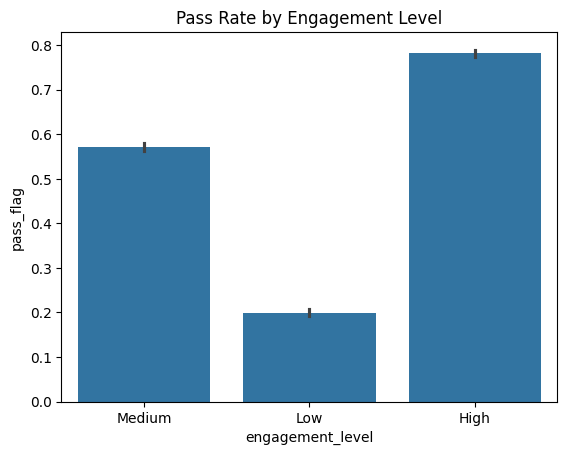

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="engagement_level", y="pass_flag", data=df)
plt.title("Pass Rate by Engagement Level")
sns.set_style("whitegrid")
plt.show()

In [10]:
df[["total_clicks", "pass_flag"]].isnull().sum()

,0
total_clicks,2852
pass_flag,0


In [11]:
df["total_clicks"]=df["total_clicks"].fillna(0)
df["pass_flag"] =df ["pass_flag"].fillna(0)

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [13]:
x=df[["total_clicks"]]
y = df["pass_flag"]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
model = LogisticRegression(max_iter=1000)
model.fit(x_scaled,y)

LogisticRegression(max_iter=1000)

In [14]:
print("Model coefficient:", model.coef_[0][0])

Model coefficient: 1.6158442072984183


<Axes: xlabel='engagement_level', ylabel='pass_flag'>

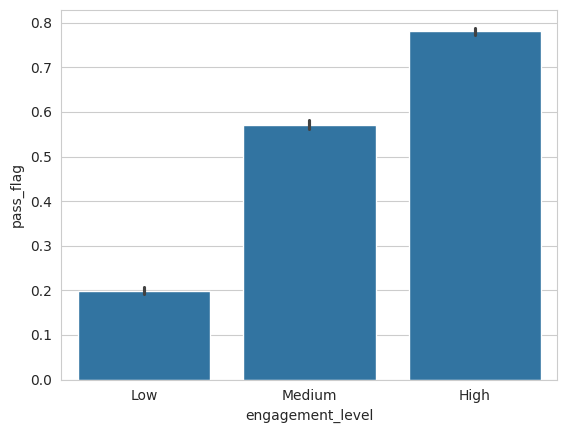

In [15]:
sns.barplot(
    x="engagement_level",
    y="pass_flag",
    data=df,
    order=["Low","Medium","High"]
)